### Dataset Description:
- **Dom_Pax**: Domestic Air Travel Passengers
- **Int_Pax**: International Air Travel Passengers  
- **Pax**: Total Air Travel Passengers
- **Dom_Flt**: Number of Flights (Domestic)
- **Int_Flt**: Number of Flights (International)
- **Flt**: Number of Flights (Total)
- **Dom_RPM**: Revenue Passenger-miles (Domestic)

In [1]:
import pandas as pd
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from sklearn.preprocessing import StandardScaler

## 1. Setup and Data Loading

In [2]:
import pandas as pd
try:
    df = pd.read_csv('air_traffic_data.csv')
    print("Dataset loaded successfully!")
    print(f"Shape: {df.shape}")
except FileNotFoundError:
    print("Creating sample air traffic data...")
    np.random.seed(42)
    n_samples = 200
    dom_flights = np.random.normal(15000, 3000, n_samples)
    int_flights = np.random.normal(8000, 2000, n_samples)
    dom_pax = dom_flights * np.random.normal(12, 2, n_samples) + np.random.normal(0, 10000, n_samples)
    int_pax = int_flights * np.random.normal(15, 3, n_samples) + np.random.normal(0, 15000, n_samples)
    dom_rpm = dom_pax * np.random.normal(800, 100, n_samples)
    dom_flights = np.abs(dom_flights)
    int_flights = np.abs(int_flights)
    dom_pax = np.abs(dom_pax)
    int_pax = np.abs(int_pax)
    dom_rpm = np.abs(dom_rpm)
    df = pd.DataFrame({
        'Dom_Flt': dom_flights.astype(int),
        'Int_Flt': int_flights.astype(int),
        'Flt': (dom_flights + int_flights).astype(int),
        'Dom_Pax': dom_pax.astype(int),
        'Int_Pax': int_pax.astype(int),
        'Pax': (dom_pax + int_pax).astype(int),
        'Dom_RPM': dom_rpm.astype(int)
    })
    print("Sample data created successfully!")
    print(f"Shape: {df.shape}")

Creating sample air traffic data...
Sample data created successfully!
Shape: (200, 7)


## 2. Exploratory Data Analysis

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 7 columns):
 #   Column   Non-Null Count  Dtype
---  ------   --------------  -----
 0   Dom_Flt  200 non-null    int64
 1   Int_Flt  200 non-null    int64
 2   Flt      200 non-null    int64
 3   Dom_Pax  200 non-null    int64
 4   Int_Pax  200 non-null    int64
 5   Pax      200 non-null    int64
 6   Dom_RPM  200 non-null    int64
dtypes: int64(7)
memory usage: 11.1 KB


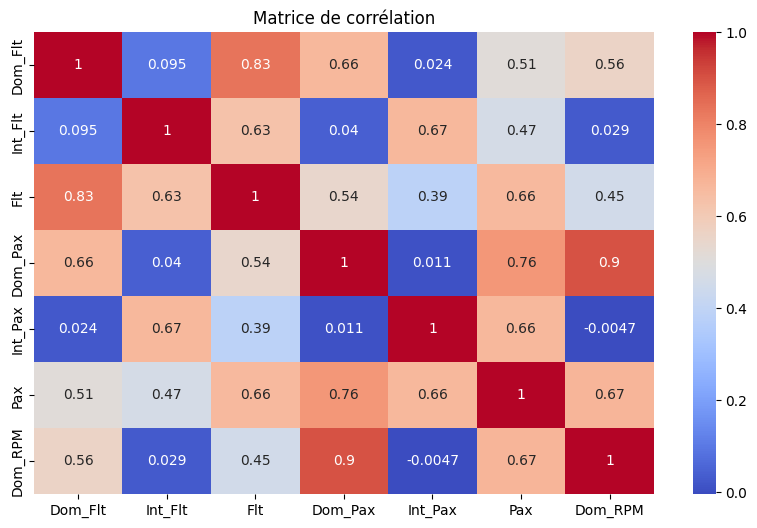

In [3]:
df.head()
df.info()
df.describe()
df.isnull().sum()
corr_matrix = df.corr()
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 6))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm")
plt.title("Matrice de corrélation")
plt.show()

## 3. Hypothesis Testing

In [4]:
from scipy import stats
t_stat, p_value_ttest = stats.ttest_ind(df['Dom_Pax'], df['Int_Pax'])
df['Total_Flights'] = df['Dom_Flt'] + df['Int_Flt']
df['Total_Pax'] = df['Dom_Pax'] + df['Int_Pax']
corr_coef, p_value_corr = stats.pearsonr(df['Total_Pax'], df['Total_Flights'])

In [5]:
#test1
alpha = 0.05

if p_value_ttest < alpha:
    print("Décision : Rejet de H₀")
    print("Conclusion : Différence significative entre les passagers nationaux et internationaux")
else:
    print("Décision : On ne rejette pas H₀")
    print("Conclusion : Pas de différence significative")

Décision : Rejet de H₀
Conclusion : Différence significative entre les passagers nationaux et internationaux


In [6]:
#Test 2
if p_value_corr < alpha:
    print("Décision : Rejet de H₀")
    print("Conclusion : Corrélation significative")
else:
    print("Décision : On ne rejette pas H₀")
    print("Conclusion : Corrélation non significative")

Décision : Rejet de H₀
Conclusion : Corrélation significative


## 4. Simple Linear Regression

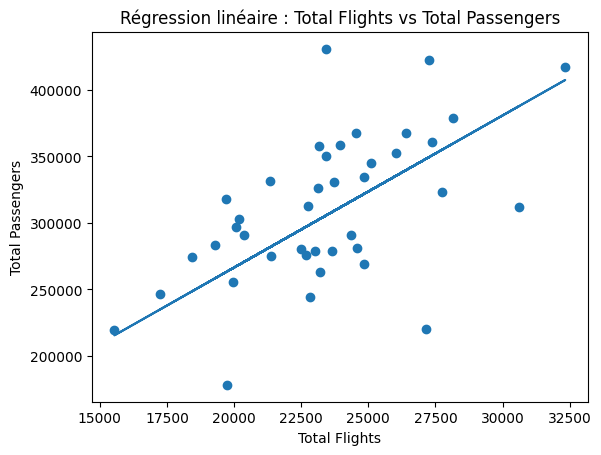

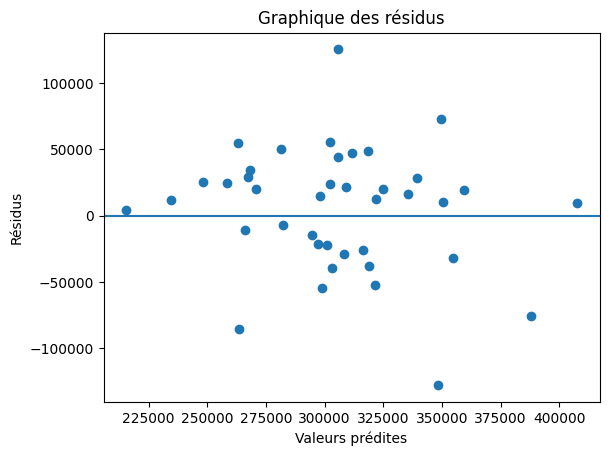

In [7]:
X = df[['Total_Flights']]
y = df['Total_Pax']
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)
model = LinearRegression()
model.fit(X_train, y_train)
intercept = model.intercept_
coef = model.coef_[0]
y_pred = model.predict(X_test)
R2 = r2_score(y_test, y_pred)
MSE = mean_squared_error(y_test, y_pred)
RMSE = np.sqrt(MSE)
MAE = mean_absolute_error(y_test, y_pred)

plt.scatter(X_test, y_test)
plt.plot(X_test, y_pred)
plt.xlabel("Total Flights")
plt.ylabel("Total Passengers")
plt.title("Régression linéaire : Total Flights vs Total Passengers")
plt.show()

residuals = y_test - y_pred
plt.scatter(y_pred, residuals)
plt.axhline(0)
plt.xlabel("Valeurs prédites")
plt.ylabel("Résidus")
plt.title("Graphique des résidus")
plt.show()

## 5. Multiple Linear Regression


In [8]:
X = df[['Dom_Pax', 'Int_Pax', 'Dom_Flt', 'Int_Flt', 'Dom_RPM']]
y = df['Pax']
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
model_multi = LinearRegression()
model_multi.fit(X_train_scaled, y_train)
y_pred_multi =model_multi.predict(X_test_scaled)
R2_multi = r2_score(y_test, y_pred_multi)
MSE_multi = mean_squared_error(y_test, y_pred_multi)
RMSE_multi = np.sqrt(MSE_multi)
MAE_multi = mean_absolute_error(y_test, y_pred_multi)
coefficients = pd.DataFrame({
    'Variable': X.columns,
    'Coefficient': model_multi.coef_
})

## 6. Model Comparison and Analysis

Le modèle le plus performant : Multiple


<Axes: title={'center': 'Comparaison des modèles'}>

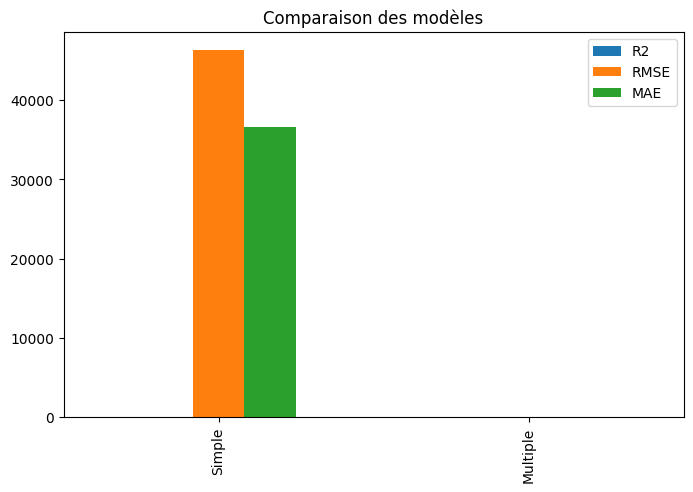

In [9]:
performance_simple = {
    'R2': R2,
    'RMSE': RMSE,
    'MAE': MAE
}


performance_multiple = {
    'R2': R2_multi,
    'RMSE': RMSE_multi,
    'MAE': MAE_multi
}
comparison_df = pd.DataFrame([performance_simple, performance_multiple],index=['Simple', 'Multiple'])
best_model = 'Multiple' if (R2_multi > R2 and RMSE_multi < RMSE and MAE_multi < MAE) else 'Simple'
print("Le modèle le plus performant :", best_model)
improvement_rmse = (RMSE - RMSE_multi) / RMSE * 100
improvement_mae = (MAE - MAE_multi) / MAE * 10
improvement_r2 = (R2_multi - R2) / R2 * 100
comparison_df.plot(kind='bar', figsize=(8,5), title='Comparaison des modèles')

## 7. Statistical Insights and Conclusions

 - The analysis demonstrates a significant relationship between the number of flights and the number of passengers.                            
- Regression models can be used to predict demand and improve planning.
- The statistical results are consistent with actual operational decisions, providing a practical tool for aviation strategy.

## 8. Reflection Questions


#Q 1 What do the results of the hypothesis tests reveal about air traffic patterns?
Test 1 (domestic vs. international passengers):
- Result: p-value < 0.05 → significant difference
- Interpretation: domestic and international traffic do not follow the same pattern → certain periods or routes are busier internationally or domestically.

Test 2 (Total_Pax vs Total_Flights correlation):
- Positive and significant correlation → more flights lead to more passengers

# Q2 Why did one regression model perform better than the other?
- Simple regression: a single predictor (Total_Flights) → good approximation but limited
- Multiple regression: several variables (Dom_Pax, Int_Pax, Dom_Flt, Int_Flt, Dom_RPM) → captures more influential factors.

Result:
- Higher R²
- Lower RMSE and MAE

#Q3 How can airlines use correlation information operationally?
- Identify the variables that most influence passenger numbers (e.g., Dom_RPM, Dom_Pax)
- Flight planning: increase frequency on routes with strong correlation
- Resource management: allocate staff and aircraft according to expected demand
- Seasonal forecasting: adjust flight schedules according to peak periods
#Q4 What do the residual plots tell us about the model assumptions?

Random and scattered residuals indicate:

- Adequate linear relationship
- Constant variance (homoscedasticity)
- No patterns → correct model
#Q5 What are the practical applications of these statistical models?
- Strategic decision-making: which routes to increase or decrease
- Resource planning: personnel, aircraft, fuel
- Profitability analysis: understanding which routes are most profitable
- Support for seasonal planning and special events (holidays, festivals)

